In [1]:
import torch
from torch import optim, nn, pi as π
from torch.nn import functional; nn.f = functional
from utils import set_plot_defaults
from utils.os import setup_save
from ctrl.plot import *
from numpy import cos, sin

In [2]:
# Reload plotting library during development
%load_ext autoreload
%autoreload 1
%aimport ctrl.plot, ctrl.truck

In [3]:
# Create pth/ and prepend pth/ to save path
save_pth = setup_save(dst='ctrl/pth/')

The folder 'ctrl/pth/' already exists.
Executing this notebook will overwrite its content.


# A tricycle model

The state transition equations are the following:

$$
\def\vx{\boldsymbol{\textcolor{#fccde5}{x}}}
\def\vu{\boldsymbol{\textcolor{#fdb462}{u}}}
\def\px{\textcolor{#fccde5}{x}}
\def\py{\textcolor{#fccde5}{y}}
\def\pt{\textcolor{#fccde5}{\vartheta}}
\def\pv{\textcolor{#fccde5}{v}}
\def\oa{\textcolor{#fdb462}{a}}
\def\op{\textcolor{#fdb462}{\varphi}}
\dot{\vx} = f(\vx, \vu) =
\left\{
\begin{array}{l}
\dot{\px} = \pv \cos \pt \\
\dot{\py} = \pv \sin \pt \\
\dot{\pt} = \frac{\pv}{\ell} \tan \op \\
\dot{\pv} = \oa
\end{array}
\right. \quad
\vx = (\px\;\py\;\pt\;\pv) \quad
\vu = (\op\;\oa)
$$

In [4]:
# Tricycle dynamics
def tricycle_dynamics(x, u):
    ℓ = 1           # m
    x, y, ϑ, v = x  # m, m, rad, m/s
    φ, a = u        # rad, m/s^2

    f = torch.zeros(4)
    f[0] = v * torch.cos(ϑ)      # m/s
    f[1] = v * torch.sin(ϑ)      # m/s
    f[2] = v / ℓ * torch.tan(φ)  # rad/s
    f[3] = a                     # m/s^2

    return f

In [5]:
def integrate(f, x0, u, dt=1):
    N = len(u)
    x = [0] * (N+1)
    x[0] = x0
    for n in range(N):
        x[n+1] = x[n] + f(x[n], u[n]) * dt
    return torch.stack(x)

In [6]:
# Forward Euler integration, return {x[n]}
def integrate2(f, x0, u, dt=1):
    N = len(u)
    x = torch.zeros(N+1, x0.size(0))
    x[0] = x0
    for n in range(N):
        x[n+1] = x[n] + f(x[n], u[n]) * dt
    return x

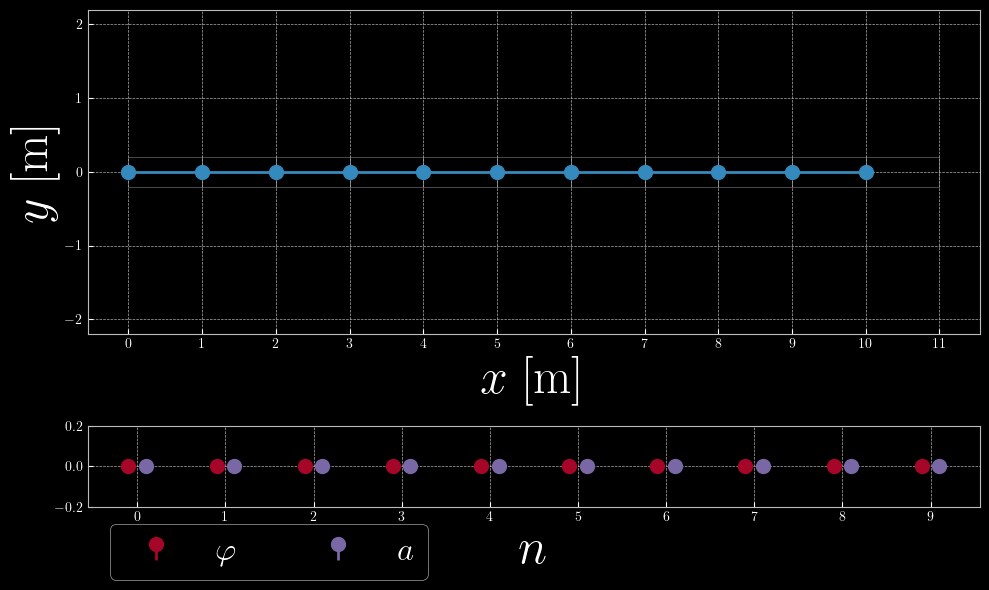

In [ ]:
# No control, v = 1 m/s
x0 = torch.tensor((0, 0, 0, 1))
u = torch.zeros(10, 2)
x = integrate(tricycle_dynamics, x0, u)
plot_xu(x, u)
del x0, x, u

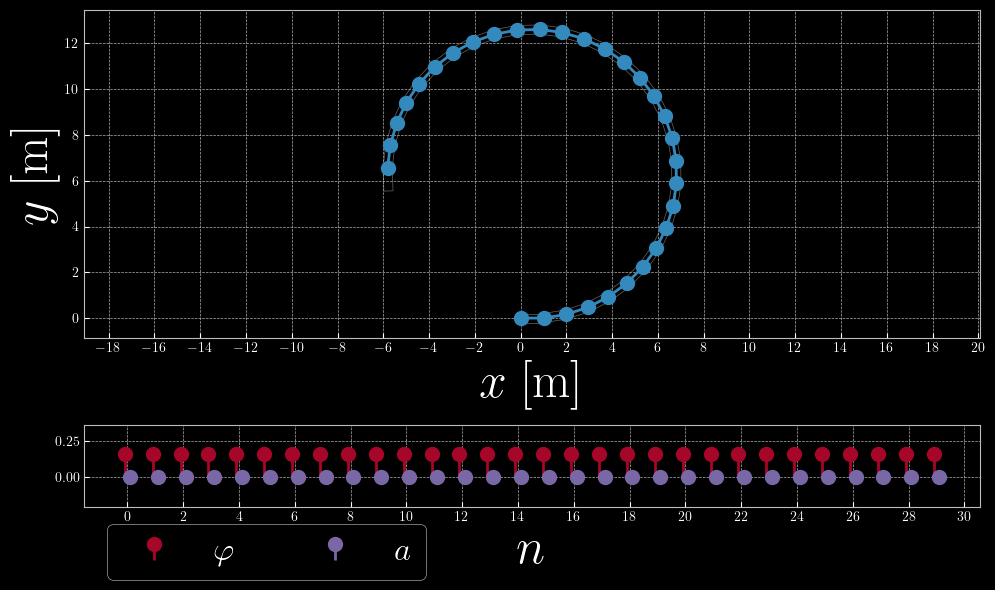

In [8]:
# Steering left 10°, v = 1 m/s
x0 = torch.tensor((0, 0, 0, 1))
u = torch.zeros(30, 2)
u[:,0] = 0.05 * π
x = integrate(tricycle_dynamics, x0, u)
plot_xu(x, u)
del x0, x, u

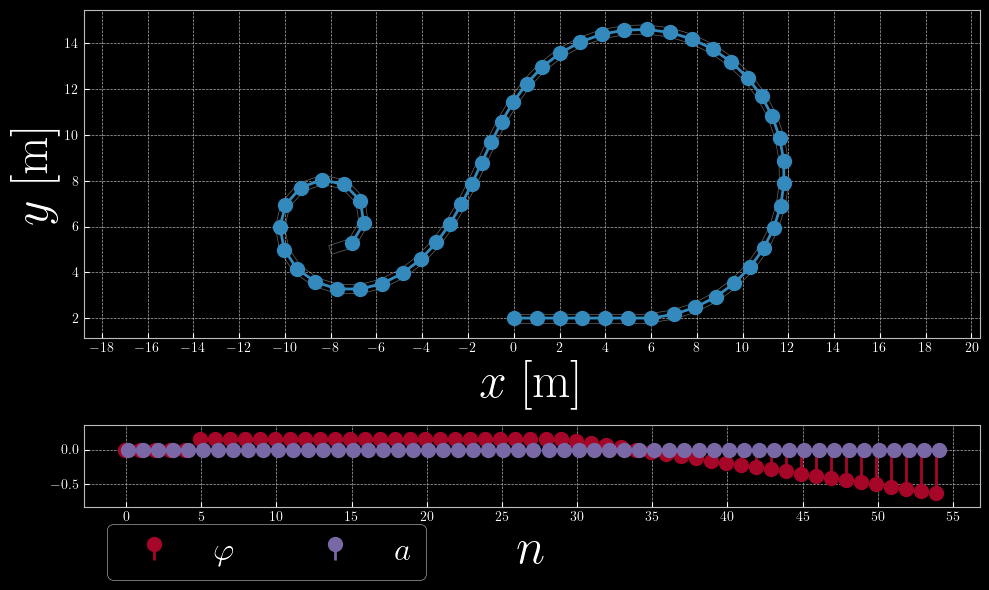

In [9]:
# Straight, steering left 0.05π, steering right more and more, v = 1 m/s
x0 = torch.tensor((0, 2, 0, 1))
u = torch.zeros(55, 2)
u[5:30,0] = 0.05 * π
u[30: ,0] = torch.linspace(0.04, -0.2, 25) * π
x = integrate(tricycle_dynamics, x0, u)
plot_xu(x, u)
save_pth((x, u), 'xu_spiral')
del x0, x

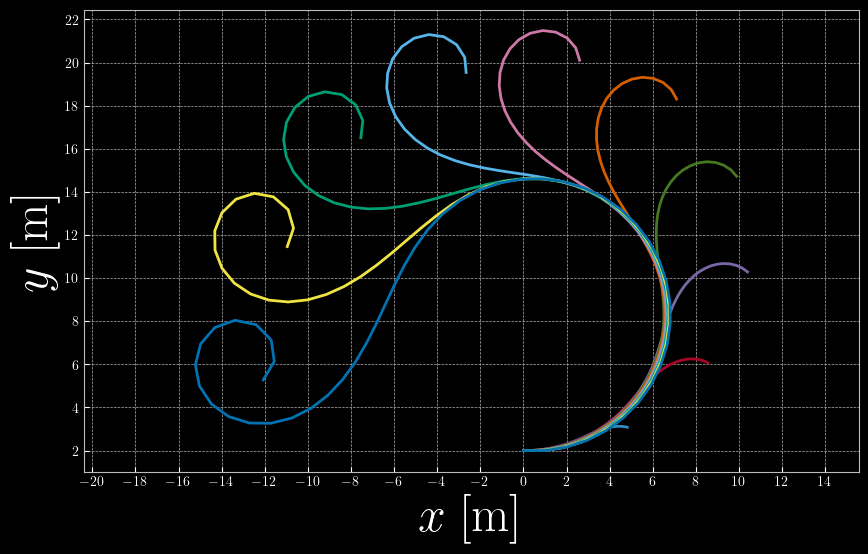

In [10]:
# Almost same control, sweep for initial velocity
K = 10
u_ = u[5:]
x = torch.zeros(len(u_)+1, 4, K)
for k in range(K):
    x0 = torch.tensor((0, 2, 0, (k+1)/10))
    x[..., k] = integrate(tricycle_dynamics, x0, u_)
plot_τ(x, fmt='-')
save_pth(x, 'x_spiral_sweep')
del x0, x, u, u_

# From the ellipse notebook (mostly copied code)

In [11]:
# Define LBFGS minimiser, copied from the Ellipse notebook, swapped u for z
def LBFGS(e, u0):
    u0 = nn.Parameter(u0)
    opt = optim.LBFGS((u0,), line_search_fn='strong_wolfe', max_iter=200)
    def closure():
        e_u0 = e(u0)
        opt.zero_grad()
        e_u0.backward()
        return e_u0
    opt.step(closure)

In [12]:
# Define computation of ǔ
def compute_ǔ(e, N, C=2):
    u = torch.zeros(N, C)  # zero control sequence {u[n]}
    LBFGS(e, u)            # update u as e minimiser
    return u               # return minimiser, i.e. ǔ

# Optimal control

In [13]:
# Define cost
C = lambda y, ỹ: (ỹ - y).pow(2).sum()

In [14]:
# Planning function, from x0 to y
def plan(x0, y, N):
    def e(u):
        x = integrate(tricycle_dynamics, x0, u)
        ỹ = x[N][:2]  # output transformation
        return C(y, ỹ)
    ǔ = compute_ǔ(e, N)
    return ǔ

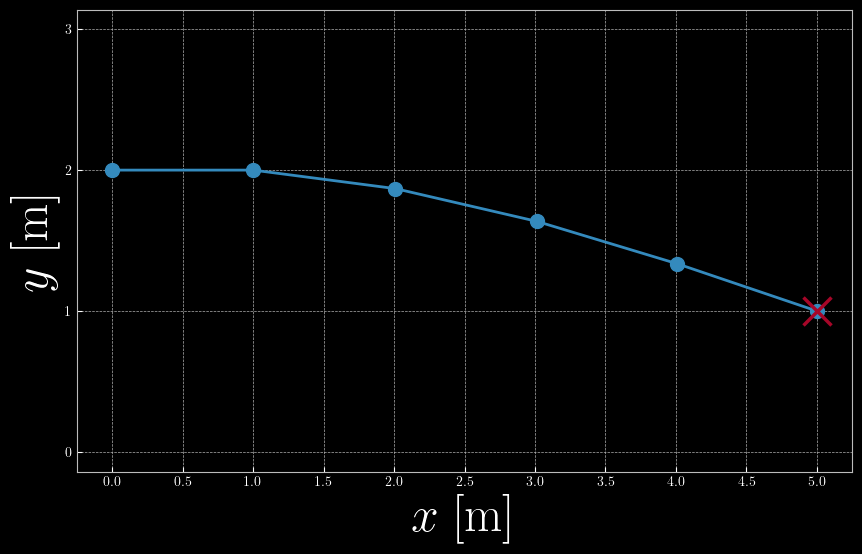

In [15]:
# Simple offset from zero control destination
x0 = torch.tensor((0, 2, 0, 1))
y = torch.tensor((5, 1))
ǔ = plan(x0, y, 5)
x = integrate(tricycle_dynamics, x0, ǔ)
plot_τ(x, y)
del x0, y, ǔ, x

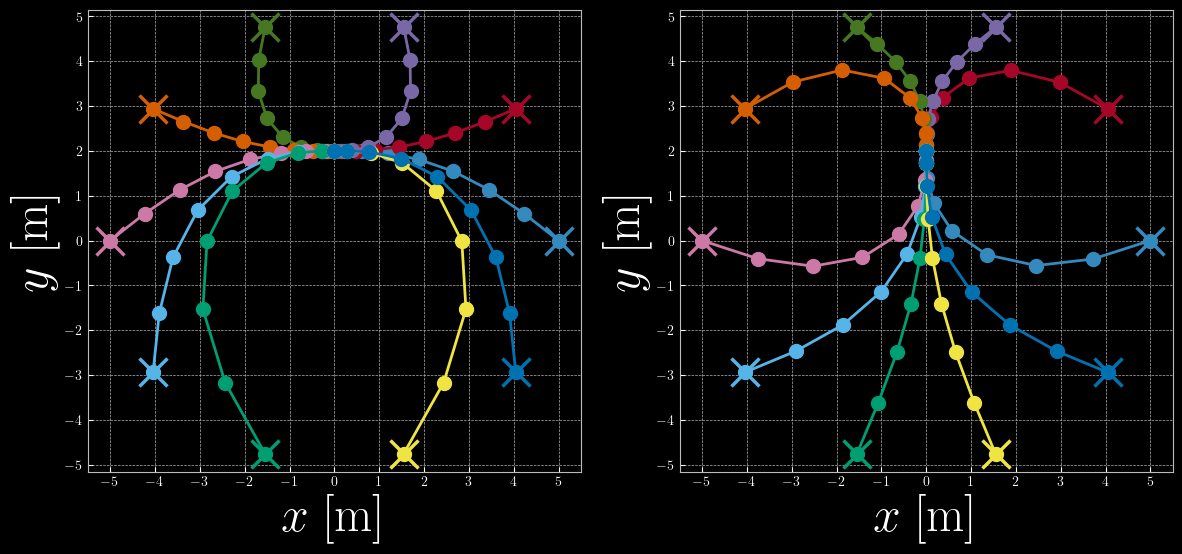

In [16]:
# Circular targets
N = 9
K = 10
y = torch.zeros(1, 2, K)
u = torch.zeros(N, 2, K, 2)
x = torch.zeros(N+1, 4, K, 2)
for a in range(2):
    x0 = torch.tensor((0, 2, π/2*a, 0))
    for k in range(K):
        α = k * 2 * π / K
        y[...,k] = 5 * torch.tensor((cos(α), sin(α)))
        u[...,k,a] = plan(x0, y[...,k], N)
        x[...,k,a] = integrate(tricycle_dynamics, x0, u[...,k,a])

plot_2_phase_planes(x, y)
save_pth((x, y, u), 'xN_to_y')
del x, y, N

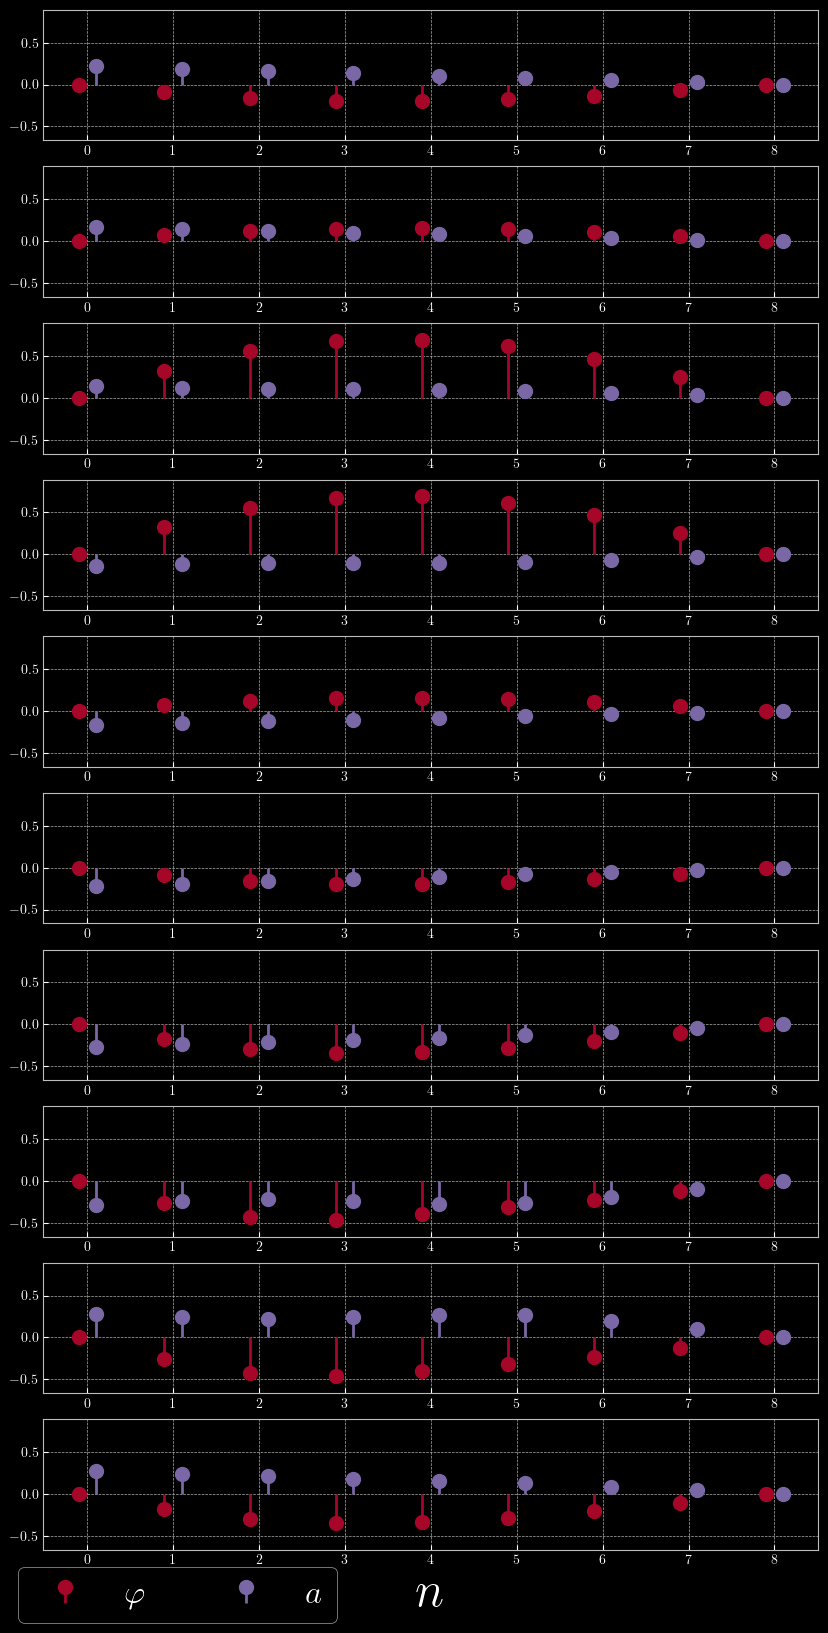

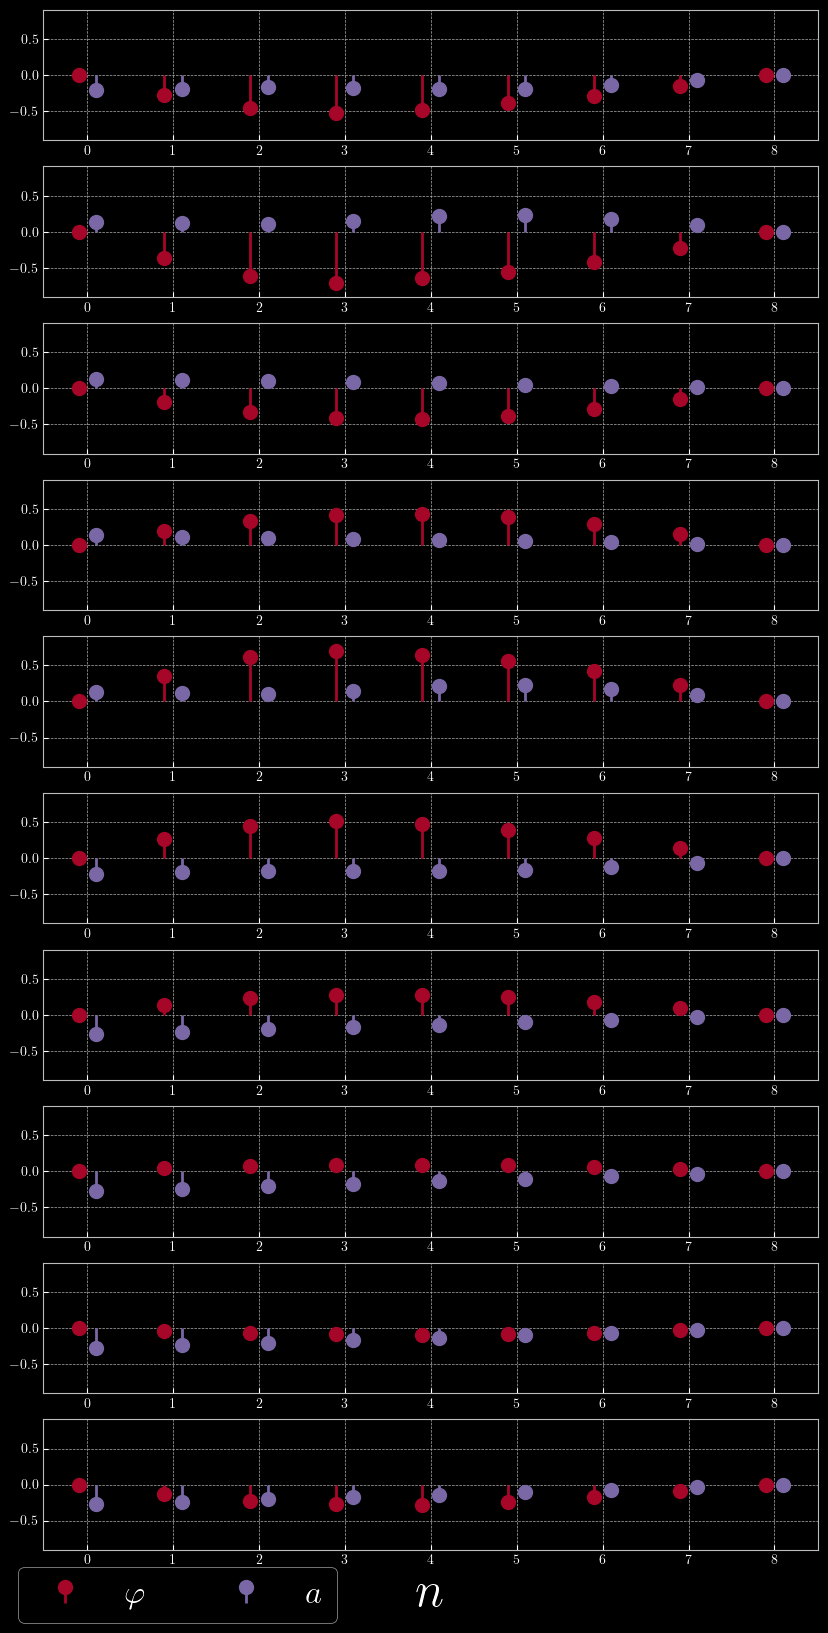

In [17]:
# Plot optimal controls
plot_multi_controls(u[...,0], K)
plot_multi_controls(u[...,1], K)
del u, K

# Truck backer upper

The `class` `Truck` has been hidden in an include file, since it contains all the visualisation methods that are not of our interest.
Here, we are reproducing just the functions that are relevant for understanding how the system works.

```python
class Truck:
    def __init__(self, lesson, display=False):
        self.W = 1           # m
        self.ℓ = 1 * self.W  # m
        self.d = 4 * self.ℓ  # m
        self.v = -0.1        # m/s
        ...
```

Car-trailer equation:

$$
\def\vx{\boldsymbol{\textcolor{#fccde5}{x}}}
\def\px{\textcolor{#fccde5}{x}}
\def\py{\textcolor{#fccde5}{y}}
\def\subcab{_{\textcolor{#fccde5}{\mathrm{cab}}}}
\def\subtrailer{_{\textcolor{#fccde5}{\mathrm{trailer}}}}
\def\ptc{\textcolor{#fccde5}{\vartheta_{\mathrm{cab}}}}
\def\ptt{\textcolor{#fccde5}{\vartheta_{\mathrm{trailer}}}}
\def\pv{\textcolor{#fccde5}{v}}
\def\op{\textcolor{#fdb462}{\varphi}}
\dot{\vx} = f(\vx, \op) =
\left\{
\begin{array}{l}
\dot{\px}\subcab = v \cos \ptc \\
\dot{\py}\subcab = v \sin \ptc \\
\dot{\pt}\subcab = v \tan \op / \ell \\
\dot{\pt}\subtrailer = v \sin(\ptt - \ptc) /d
\end{array}
\right. \quad
\vx = (\px\subcab\;\py\subcab\;\ptc\;\ptt)
$$

The method `step` performs a single forward Euler integration step and returns the next state `x[n+1]`.

```python
def step(self, φ=0, dt=1):
    ...
    self.φ = φ
    x, y, W, ℓ, d, v, ϑ_cab, ϑ_trailer, φ = self._get_atributes()
    
    self.x         += v * cos(ϑ_cab) * dt
    self.y         += v * sin(ϑ_cab) * dt
    self.ϑ_cab     += v * tan(φ) / ℓ * dt
    self.ϑ_trailer += v * sin(ϑ_cab - ϑ_trailer) / d * dt
    ...
    return next_state
```


In [18]:
import torch
from torch import optim, nn, pi as π
from torch.nn import functional; nn.f = functional
from utils import set_plot_defaults
from utils.os import setup_save
from ctrl.plot import *
from ctrl.truck import *
from numpy import cos, sin

In [19]:
# Reload plotting library during development
%load_ext autoreload
%autoreload 1
%aimport ctrl.plot, ctrl.truck

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
%matplotlib widget

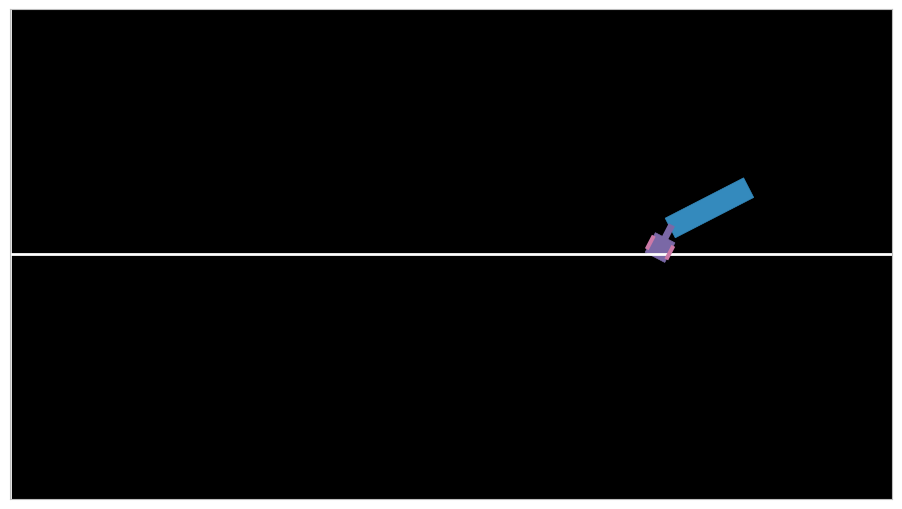

In [21]:
# Running this cell multiple times will cause orphan figures
truck = Truck(display=True)
truck.reset()

In [22]:
φ = deg2rad(45)  # positive left, negative right
truck.step(φ)
truck.draw()

In [23]:
truck.reset()

In [24]:
def test_fun(i):
    if i >= 5: return
    return True

In [26]:
# while t

In [27]:
# Generate jackknifing trajectory
truck.reset()
x0 = truck.set(6, 1, deg2rad(10), deg2rad(-20))
truck.draw()
x = [torch.tensor(x0)]
φ = deg2rad(45)
while True:
    x_n = truck.step(φ)
    if x_n is None: break
    x.append(torch.tensor(x_n))
    truck.draw()
x = torch.stack(x)
save_pth(x, 'truck_trajectory')

The truck is jackknifed!


In [28]:
x[:,2].rad2deg_()

tensor([  10.0000,    4.2704,   -1.4592,   -7.1887,  -12.9183,  -18.6479,
         -24.3775,  -30.1070,  -35.8366,  -41.5662,  -47.2958,  -53.0254,
         -58.7549,  -64.4845,  -70.2141,  -75.9437,  -81.6732,  -87.4028,
         -93.1324,  -98.8620, -104.5916], dtype=torch.float64)

In [29]:
x[:,5].rad2deg_()

tensor([-20.0000, -20.7162, -21.3213, -21.8079, -22.1694, -22.3997, -22.4934,
        -22.4464, -22.2554, -21.9190, -21.4374, -20.8127, -20.0491, -19.1534,
        -18.1347, -17.0048, -15.7778, -14.4703, -13.1010, -11.6902, -10.2595],
       dtype=torch.float64)

In [30]:
x[10]

tensor([  5.0769,   1.2609, -47.2958,   1.3536,   2.7229, -21.4374],
       dtype=torch.float64)

In [31]:
n = 20
print(f'\\drawcab{{{x[n][0]:.4f}}}{{{x[n][1]:.4f}}}{{{x[n][2]:.4f}}}')

\drawcab{4.7977}{2.1786}{-104.5916}


In [32]:
x.size()

torch.Size([21, 6])

In [33]:
save_pth(x, 'truck_trajectory')

# Scratchpad below

In [34]:
plt.plot(y[0], y[1])
plt.axis('equal')

NameError: name 'plt' is not defined

In [ ]:
y is not None

In [ ]:
u

In [ ]:
x0 = torch.tensor((0, 2, 0, 1))
x = integrate(tricycle_dynamics, x0, u)

In [ ]:
plot_τ(x)

In [ ]:
compute_ǔ(E, N)

In [ ]:
def e(u):
    x0 = torch.tensor((0, 2, 0, 1))
    x = integrate(tricycle_dynamics, x0, u)
    return (x[-1][:2] - y).pow(2).sum()
y = torch.tensor((5, 1))

In [ ]:
e(torch.zeros(5, 2))

In [ ]:
from torch.optim import SGD

In [ ]:
u = nn.Parameter(torch.zeros(5, 2))
opt = SGD((u,), lr=0.01)
x0 = torch.tensor((0, 2, 0, 1))
y = torch.tensor((5, 1))
for _ in range(15):
    x = integrate2(tricycle_dynamics, x0, u)
    E = (x[-1,:2] - y).pow(2).sum()
    print(E.item())
    opt.zero_grad()
    E.backward()
    opt.step()

Try with append rather than assign… But it's annoying.

In [ ]:
# No control, v = 1 m/s
x0 = torch.tensor((0, 0, 0, 1))
u = torch.zeros(10, 2)
x = integrate2(tricycle_dynamics, x0, u)
plot_xu(x, u)
# del x0, x, u

In [ ]:
torch.stack(x).size()

In [ ]:
ǔ = plan()